# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Available threads: 1
RHO_unit:3.906325282703709e-19


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethodGRMHD**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [2]:
dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

In [3]:
#TODO: put this in reading file
const N1 = 128
const N2 = 64
const N3 = 32

const METRIC = "FMKS" #FMKS or MKS TODO: prob have to be read from file
const trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (13. /9.)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1.0 #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.0
const startx::MVec4 = [0, 1.874000951149813e-03, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1, 6.907755278982138e+00, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 5.395219748461709e-02, 1.562500000000000e-02, 1.963495408493621e-01]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [4]:
const simulation_data = load_data(dump_filepath);

Loading data from '../src/models/iharm3dDumps/dump_001.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (128, 64, 32)
Calculating physical quantities...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.0, and beta_crit = 1.0
All primitives successfully loaded. Dimensions: (128, 64, 32)


In [5]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 40
const pixels_y = 40
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000


15000

In [6]:
include("../src/main.jl")
#Define the number of pixels for each image
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_da_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny

#Here we run the Autodiff method
const percentage_old = Ref(0.0)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_da_out = Ref{Float64}(0.0)
        AutoDiffGeoTrajEulerMethod_GRMHD!(thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
            ro, th, phi, bhspin, nx, ny, nmaxstep, i, j, freq, fovx, fovy, Rout, Rstop, simulation_data)
        dI_da_arr[i + 1, j + 1] = dI_da_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]
        progress[Threads.threadid()] += 1
        if Threads.threadid() == 1
            total_progress = sum(progress)
            percentage = (total_progress / total) * 100
            
            if((percentage - percentage_old[]) > 5)
                println("Progress: $total_progress / $total ($(round(percentage, digits=2))%)")
                percentage_old[] = percentage
            end
        end
    end
end

total_progress = sum(progress)
percentage = (total_progress / total) * 100
println("Final Progress: $(total_progress/total) ($percentage%)")

Progress: 81 / 1600 (5.06%)
Progress: 162 / 1600 (10.12%)
Progress: 243 / 1600 (15.19%)
Progress: 324 / 1600 (20.25%)
Progress: 405 / 1600 (25.31%)
Progress: 486 / 1600 (30.38%)
Progress: 567 / 1600 (35.44%)
Progress: 648 / 1600 (40.5%)
Progress: 729 / 1600 (45.56%)
Progress: 810 / 1600 (50.62%)
Progress: 891 / 1600 (55.69%)
Progress: 971 / 1600 (60.69%)
Progress: 1052 / 1600 (65.75%)
Progress: 1133 / 1600 (70.81%)
Progress: 1214 / 1600 (75.88%)
Progress: 1295 / 1600 (80.94%)
Progress: 1376 / 1600 (86.0%)
Progress: 1457 / 1600 (91.06%)
Progress: 1538 / 1600 (96.12%)
Final Progress: 1.0 (100.0%)


# Plotting the Image

Plotting the image and the derivatives with proper angular spacing

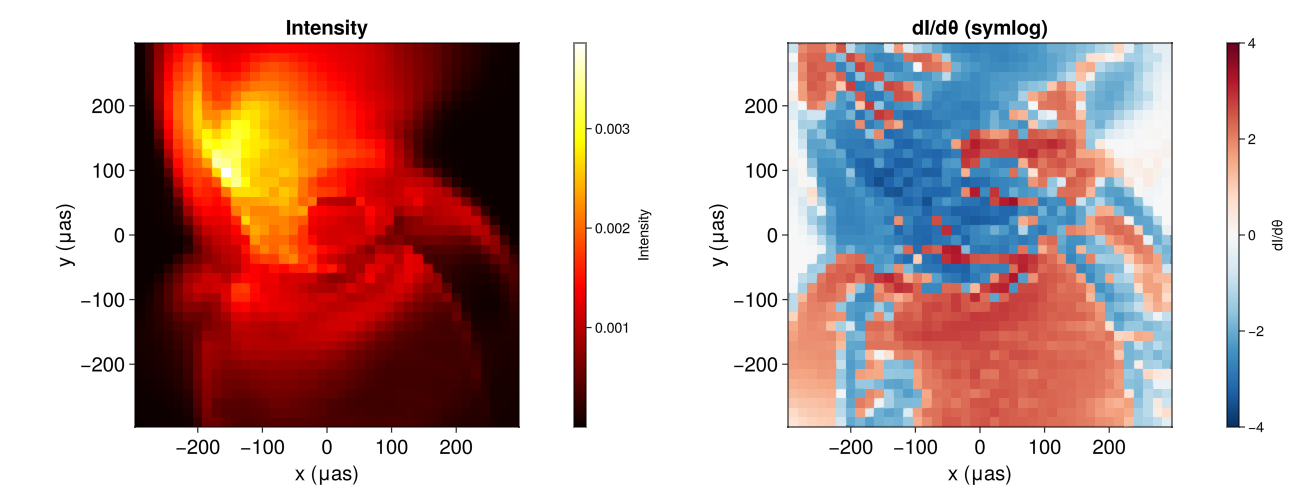

In [7]:
using GLMakie

# Calculate field of view limits
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 160
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# Symlog parameters
# -----------------------------
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# -----------------------------
# Symlog transform
# -----------------------------
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh)

cr_symlog = (
    - (1 + log10(abs(vmin) / linthresh)),
      (1 + log10(abs(vmax) / linthresh))
)

# -----------------------------
# Figure layout (side colorbars)
# -----------------------------
fig = Figure(size = (1300, 500))

# -----------------------------
# Plot 1: Intensity
# -----------------------------
ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot
)

Colorbar(fig[1, 2], hm1;
    label = "Intensity"
)

# -----------------------------
# Plot 2: dI/dθ (symlog)
# -----------------------------
ax2 = Axis(fig[1, 3],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 4], hm2;
    label = "dI/dθ"
)



fig


# Conjugate gradient parameter recovery

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `spin_value` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [8]:
spin_value = 0.9375
initial_th_guess = 19.4
ths, _, err, steps = true_conjugate_gradient_optimization(I_arr, ro, initial_th_guess, spin_value, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 6e-14, optimize_param = :theta, simulation_data)

Optimization mode: theta
Optimizing θo: true, Optimizing a: false
Running AutoDiffGeoTrajEulerMethod with θo = 19.4, a = 0.9375 and applying σ_pixels = 0.0 filter
  Convergence check: cost=0.001930371731482792, grad_norm=0.009110246234764998
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.001930371731482792, Initial θo: 19.4, Initial a: 0.9375
Initial gradient norm: 0.009110246234764998

--- Iteration 1 ---
Trying aggressive initial step: 32.929955159190996, set at iteration 1
Cost before line search: 0.001930371731482792
Using cached computation for x = [0.3233333333333333, 1.5625]
grad = [-0.009110246234764998, 0.0], direction = [0.009110246234764998, 0.0]
  Line search: f0=0.001930371731482792, df0=-8.299658645804982e-5, initial_step=32.929955159190996
Running AutoDiffGeoTrajEulerMethod with θo = 37.4, a = 0.9375 and applying σ_pixels = 0.0 filter
  Step 1: step_size=32.929955159190996, f_new=0.0003239446642915097, improvement=0.0016064270671912824, s

([19.4, 37.4, 55.4, 64.39999999999999, 59.9, 60.040625000000006, 59.9703125, 60.00546874999999, 60.00546874999999], [0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375], [0.001930371731482792, 0.0003239446642915097, 2.1339892911807664e-5, 1.7556634066418388e-5, 8.945589253218425e-8, 3.32623849947805e-8, 3.140127620629755e-8, 4.796167451551984e-9, 4.796167451551984e-9], 200)

Plot theta, spin and error evolution at each iteration step

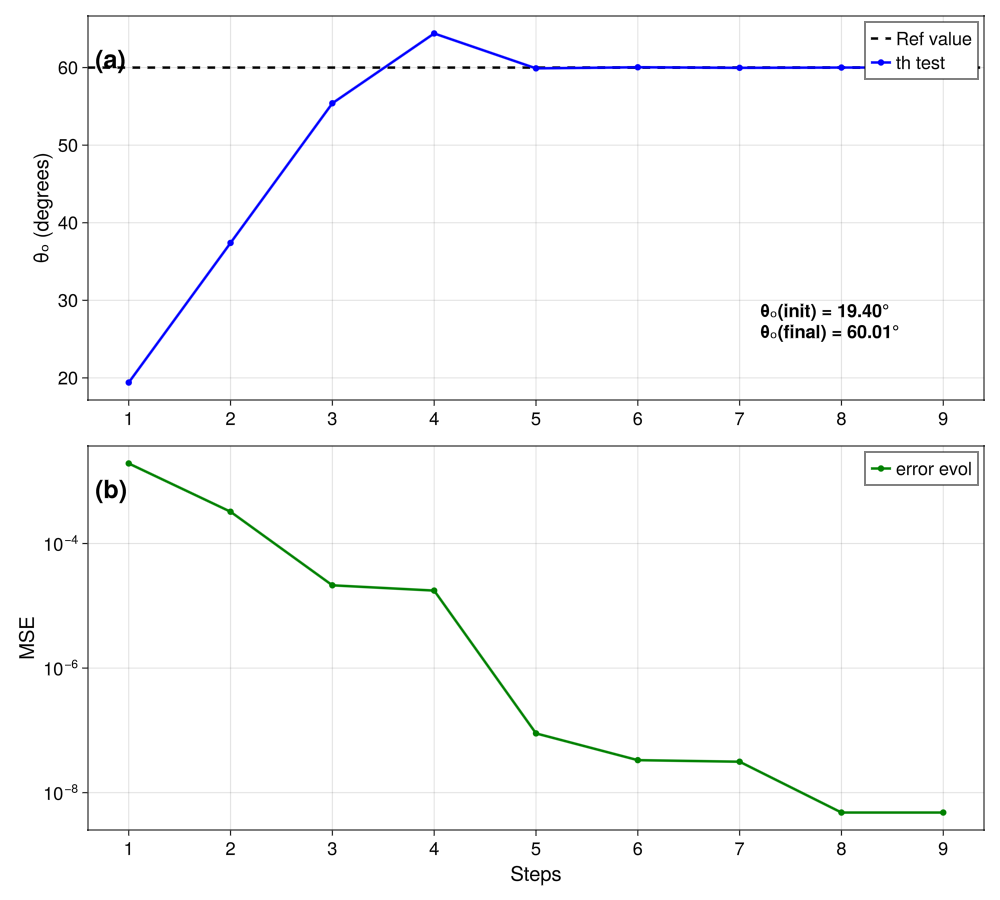

In [11]:
using GLMakie

fig = Figure(size = (1000, 900))
xticks = 0:9

# -----------------------------
# (a) Plot θₒ
# -----------------------------
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# Get initial and final values to print out on top of the figure
θ_init = ths[1]
θ_final = ths[end]


label_text = @sprintf("θₒ(init) = %.2f°\nθₒ(final) = %.2f°", θ_init, θ_final)

text!(
    ax1,
    0.75, 0.15,              
    text = label_text,
    space = :relative,
    fontsize = 18,
    align = (:left, :bottom),
    font = :bold
)

# -----------------------------
# (b) Plot Error
# -----------------------------
ax3 = Axis(fig[2, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax3)

# Display and save
save("../imgs/th_convergence_nonoise_bottom.png", fig)
fig